In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

csv_data = """Voltage,Vitesse_testo,Hauteur,
57.5,4.67,0.7181,
54.9, 4.46, 0.7220,
45,3.56,0.7477,
35,2.73,0.7642,
25, 1.87, 0.7782,
20,1.47,0.7833,
10,0.57,0.7885,
0,0, 0.7894,
"""
RHO_ALCOOL = 24 / 30 * 981
RHO_AIR = 1.2       # kg/m3
G = 9.81            # m/s2

df = pd.read_csv(io.StringIO(csv_data))

#valeur de référence (voltage == 0)
h0 = df.loc[df['Voltage'] == 0, 'Hauteur'].values[0]

#en pouces (Zéro - Valeur mesurée)
df['Delta_H_in'] = h0 - df['Hauteur']

#en mètres
df['Delta_H_m'] = df['Delta_H_in'] * 0.0254

#pression différentielle (Pa) : dP = rho * g * h
df['Pression_Pa'] = RHO_ALCOOL * G * df['Delta_H_m']

#avec Bernoulli
df['Vitesse_Pitot'] = np.sqrt(np.maximum((2 * df['Pression_Pa']) / RHO_AIR, 0))

df_clean = df[['Voltage', 'Vitesse_Pitot']]
df_clean.to_csv("tunel_viento_v2.csv", index=False)
print("Données traitées et sauvegardées dans 'tunel_viento_v2.csv'.\n")
print(df_clean.to_string(index=False))

def veloc_tunel(V):
    try:
        tunel_v = pd.read_csv('tunel_viento_v2.csv', header=0)
        deltaV, U = tunel_v.to_numpy().T
        p1 = np.polyfit(deltaV, U, 1)
        UdeltaV = np.poly1d(p1)
        if not np.isscalar(V):
            velocidad = np.zeros_like(V)
            for i, Vi in enumerate(V):
                velocidad[i] = UdeltaV(Vi) if Vi != 0 else 0
        else:
            velocidad = UdeltaV(V) if V != 0 else 0
        return float(velocidad)
    except FileNotFoundError:
        return 0.0

Données traitées et sauvegardées dans 'tunel_viento_v2.csv'.

 Voltage  Vitesse_Pitot
    57.5       4.820588
    54.9       4.686895
    45.0       3.686577
    35.0       2.865864
    25.0       1.910576
    20.0       1.410003
    10.0       0.541597
     0.0       0.000000


In [2]:
#D et Cd libres
import numpy as np
from scipy.signal import find_peaks
from sklearn.linear_model import Ridge
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress


# Paramètres physiques
L_flag_s = 0.125
L_flag_mm_s = 125.0
rho_50 = 1305
m_flag = rho_50 * 50e-6  
B_flag = 4.3e-5 
rho_air = 1.2 
H_flag_s = 0.026 
fps = 1000.0
volts = [50.0, 50.8, 52.0, 53.0, 54.0, 56.0, 58.0, 46.0, 46.5, 47.0, 47.5, 48.0, 48.5, 49.0, 49.5]
   
# Racines pour les modes d'Euler-Bernoulli
beta_L = np.array([1.87510407, 4.69409113, 7.85475744, 10.99554073])

def mode_EB(x, beta_L_val, L):
    b = beta_L_val / L
    sigma = (np.cosh(beta_L_val) + np.cos(beta_L_val)) / (np.sinh(beta_L_val) + np.sin(beta_L_val))
    return np.cosh(b*x) - np.cos(b*x) - sigma * (np.sinh(b*x) - np.sin(b*x))

def mode_EB_dx2(x, beta_L_val, L):
    b = beta_L_val / L
    sigma = (np.cosh(beta_L_val) + np.cos(beta_L_val)) / (np.sinh(beta_L_val) + np.sin(beta_L_val))
    return (b**2) * (np.cosh(b*x) + np.cos(b*x) - sigma * (np.sinh(b*x) + np.sin(b*x)))

def mode_EB_dx4(x, beta_L_val, L):
    b = beta_L_val / L
    return (b**4) * mode_EB(x, beta_L_val, L)

results = []

for v in volts:
    print(f"\nTraitement de la prise {v} V...")
    U_vent = veloc_tunel(v)
    data = np.load(f'new_data_out/{v}_slender.npz') #en vrai c'est 1000Hz
    
    Y_brut = np.array(data['Y'], dtype=float)
    S_brut = np.array(data['S'][0], dtype=float)


    Y_forme_moyenne = np.mean(Y_brut, axis=0)
    slope, intercept, _, _, _ = linregress(S_brut, Y_forme_moyenne)
    angle_rad = np.arctan(slope)
    
    Y_corrige = np.zeros_like(Y_brut)
    cos_a, sin_a = np.cos(-angle_rad), np.sin(-angle_rad)
    for i in range(Y_brut.shape[0]):
        Y_corrige[i, :] = S_brut * sin_a + Y_brut[i, :] * cos_a


    dt_brut = 1.0 / fps
    dt = dt_brut * (U_vent / L_flag_s) # dt adimensionné
    
    #données réaxées pour Euler-Bernoulli 
    s_axis = S_brut / L_flag_mm_s 
    Y = Y_corrige / L_flag_mm_s 

    nb_modes = 4
    Phi = np.zeros((len(s_axis), nb_modes))
    Phi_dx2 = np.zeros((len(s_axis), nb_modes))
    Phi_dx4 = np.zeros((len(s_axis), nb_modes))
    
    for i in range(nb_modes):
        s_physique = s_axis * L_flag_s 
        Phi[:, i] = mode_EB(s_physique, beta_L[i], L_flag_s)
        Phi_dx2[:, i] = mode_EB_dx2(s_physique, beta_L[i], L_flag_s) * (L_flag_s**2)
        Phi_dx4[:, i] = mode_EB_dx4(s_physique, beta_L[i], L_flag_s) * (L_flag_s**4)

    Y_pur = np.zeros_like(Y)
    Y_ss_pur = np.zeros_like(Y)
    Y_ssss_pur = np.zeros_like(Y)

    for i in range(Y.shape[0]):
        coefs, _, _, _ = np.linalg.lstsq(Phi, Y[i, :], rcond=None)
        Y_pur[i, :]      = np.dot(Phi, coefs)
        Y_ss_pur[i, :]   = np.dot(Phi_dx2, coefs)
        Y_ssss_pur[i, :] = np.dot(Phi_dx4, coefs)


    Y_centré = Y_corrige - np.mean(Y_corrige, axis=0)
    

    U_svd, Sigma_svd, Vt_svd = np.linalg.svd(Y_centré, full_matrices=False)
    Y_propre = np.dot(U_svd[:, :2] * Sigma_svd[:2], Vt_svd[:2, :])
    
    tip_signal_t = Y_propre[:, -1] / 1000.0
    
    # amplitude Statistique (RMS)
    amplitude_moyenne_t = np.std(tip_signal_t) * np.sqrt(2)
    
    # fréquence (Passages par zéro)
    zero_crossings = np.where(np.diff(np.sign(tip_signal_t)))[0]
    if len(zero_crossings) < 4:
        print(f"  -> Attention, pas assez d'oscillations détectées pour {v} V.")
        continue
        
    periodes_en_points_t = np.diff(zero_crossings[::2]) 
    periode_moyenne_sec_t = np.mean(periodes_en_points_t) / fps
    freq_precise_t = 1.0 / periode_moyenne_sec_t
    
    # vitesse instantanée pour chaque frame
    v_tip_instantanee_t = np.gradient(tip_signal_t, dt_brut) 
    
    # "Vitesse Crête Typique" avec la méthode RMS
    v_tip_reelle_t = np.std(v_tip_instantanee_t) * np.sqrt(2)
    
    #comparaison avec le modèle harmonique 
    v_tip_harmonique_t = 2 * np.pi * freq_precise_t * amplitude_moyenne_t
    print(f"Vitesse Harmonique: {v_tip_harmonique_t:.3f} | Vitesse Réelle: {v_tip_reelle_t:.3f}")
    m_air_displaced_t = rho_air * np.pi * H_flag_s / 4
    

    Y_t = np.gradient(Y_pur, dt, axis=0)
    Y_tt = np.gradient(Y_t, dt, axis=0)
    Y_ts = np.gradient(Y_t, s_axis, axis=1) 

    b_time = 5 
    b_space = 5
    
    Y_tt_flat = Y_tt[b_time:-b_time, b_space:-b_space].flatten()
    Y_ts_flat = Y_ts[b_time:-b_time, b_space:-b_space].flatten()
    Y_ss_flat = Y_ss_pur[b_time:-b_time, b_space:-b_space].flatten()
    Y_ssss_flat = Y_ssss_pur[b_time:-b_time, b_space:-b_space].flatten()

    Y_s_flat = np.gradient(Y_pur, s_axis, axis=1)[b_time:-b_time, b_space:-b_space].flatten()
    Y_t_flat = Y_t[b_time:-b_time, b_space:-b_space].flatten()
    
    W_norm = Y_s_flat + Y_t_flat
    Y_resis_flat = np.abs(W_norm) * W_norm

    X_features = np.column_stack([Y_ts_flat, Y_ss_flat, Y_ssss_flat, Y_resis_flat])
    target = Y_tt_flat

    X_scales = np.std(X_features, axis=0)
    X_scales[X_scales == 0] = 1.0 
    X_features_scaled = X_features / X_scales

    modele = Ridge(alpha=5.0, fit_intercept=False) 
    modele.fit(X_features_scaled, target)
    vrais_coefs = modele.coef_ / X_scales

    C_ts = vrais_coefs[0]
    C_ss = vrais_coefs[1]
    C_ssss = vrais_coefs[2]
    C_resis = vrais_coefs[3]

    M_air_t = (-C_ts * m_flag) / (2 + C_ts)
    M_totale_t = m_flag + M_air_t
    Tension_moyenne_t = (U_vent**2) * (C_ss * M_totale_t + M_air_t)
    Cd_calcule_t = - (2 * M_totale_t * C_resis) / (rho_air * L_flag_s)
    D_calcule_t = - C_ssss * M_totale_t * (U_vent**2) * (L_flag_s**2)

    results.append({
        'Volts': v,
        'U_vent': round(U_vent, 3),
        'Amplitude_m': round(amplitude_moyenne_t, 4),
        'Frequence_Hz': round(freq_precise_t, 3),
        'V_harm_ms': round(v_tip_harmonique_t, 3),
        'V_battement_ms': round(v_tip_reelle_t, 3),
        'M_air_cylindre_kg': round(m_air_displaced_t, 6),
        'M_air_SINDy_kg': round(M_air_t, 6),
        'Tension_N_m': round(Tension_moyenne_t, 4),
        'Cd_SINDy': round(Cd_calcule_t, 3),
        'Rigidite_D': round(D_calcule_t, 8)
    })

df_final = pd.DataFrame(results)
print("\n=== Synthèse Complète ===")
print(df_final.sort_values(by="Volts"))
df_final.to_csv('synthese_complete.csv', index=False)


Traitement de la prise 50.0 V...
Vitesse Harmonique: 1.413 | Vitesse Réelle: 1.444

Traitement de la prise 50.8 V...
Vitesse Harmonique: 1.160 | Vitesse Réelle: 1.207

Traitement de la prise 52.0 V...
Vitesse Harmonique: 2.051 | Vitesse Réelle: 2.056

Traitement de la prise 53.0 V...
Vitesse Harmonique: 2.196 | Vitesse Réelle: 2.199

Traitement de la prise 54.0 V...
Vitesse Harmonique: 1.560 | Vitesse Réelle: 1.565

Traitement de la prise 56.0 V...
Vitesse Harmonique: 1.620 | Vitesse Réelle: 1.627

Traitement de la prise 58.0 V...
Vitesse Harmonique: 1.422 | Vitesse Réelle: 1.429

Traitement de la prise 46.0 V...
Vitesse Harmonique: 1.311 | Vitesse Réelle: 1.323

Traitement de la prise 46.5 V...
Vitesse Harmonique: 1.448 | Vitesse Réelle: 1.461

Traitement de la prise 47.0 V...
Vitesse Harmonique: 1.612 | Vitesse Réelle: 1.644

Traitement de la prise 47.5 V...
Vitesse Harmonique: 1.622 | Vitesse Réelle: 1.667

Traitement de la prise 48.0 V...
Vitesse Harmonique: 1.831 | Vitesse Réelle

In [3]:
#rigidité imposée

results = []

for v in volts:
    print(f"\nTraitement de la prise {v} V...")
    U_vent = veloc_tunel(v)
    data = np.load(f'new_data_out/{v}_slender.npz')
    
    Y_brut = np.array(data['Y'], dtype=float)
    S_brut = np.array(data['S'][0], dtype=float)


    Y_forme_moyenne = np.mean(Y_brut, axis=0)
    slope, intercept, _, _, _ = linregress(S_brut, Y_forme_moyenne)
    angle_rad = np.arctan(slope)
    
    Y_corrige = np.zeros_like(Y_brut)
    cos_a, sin_a = np.cos(-angle_rad), np.sin(-angle_rad)
    for i in range(Y_brut.shape[0]):
        Y_corrige[i, :] = S_brut * sin_a + Y_brut[i, :] * cos_a


    dt_brut = 1.0 / fps
    dt = dt_brut * (U_vent / L_flag_s) # dt adimensionné
    
    #données réaxées pour Euler-Bernoulli 
    s_axis = S_brut / L_flag_mm_s
    Y = Y_corrige / L_flag_mm_s

    nb_modes = 4
    Phi = np.zeros((len(s_axis), nb_modes))
    Phi_dx2 = np.zeros((len(s_axis), nb_modes))
    Phi_dx4 = np.zeros((len(s_axis), nb_modes))
    
    for i in range(nb_modes):
        s_physique = s_axis * L_flag_s
        Phi[:, i] = mode_EB(s_physique, beta_L[i], L_flag_s)
        Phi_dx2[:, i] = mode_EB_dx2(s_physique, beta_L[i], L_flag_s) * (L_flag_s**2)
        Phi_dx4[:, i] = mode_EB_dx4(s_physique, beta_L[i], L_flag_s) * (L_flag_s**4)

    Y_pur = np.zeros_like(Y)
    Y_ss_pur = np.zeros_like(Y)
    Y_ssss_pur = np.zeros_like(Y)

    for i in range(Y.shape[0]):
        coefs, _, _, _ = np.linalg.lstsq(Phi, Y[i, :], rcond=None)
        Y_pur[i, :]      = np.dot(Phi, coefs)
        Y_ss_pur[i, :]   = np.dot(Phi_dx2, coefs)
        Y_ssss_pur[i, :] = np.dot(Phi_dx4, coefs)


    Y_centré = Y_corrige - np.mean(Y_corrige, axis=0)
    

    U_svd, Sigma_svd, Vt_svd = np.linalg.svd(Y_centré, full_matrices=False)
    Y_propre = np.dot(U_svd[:, :2] * Sigma_svd[:2], Vt_svd[:2, :])
    
    tip_signaL_flag_s = Y_propre[:, -1] / 1000.0
    
    # amplitude Statistique (RMS)
    amplitude_moyenne_t = np.std(tip_signaL_flag_s) * np.sqrt(2)
    
    # fréquence (Passages par zéro)
    zero_crossings = np.where(np.diff(np.sign(tip_signaL_flag_s)))[0]
    if len(zero_crossings) < 4:
        print(f"  -> Attention, pas assez d'oscillations détectées pour {v} V.")
        continue
        
    periodes_en_points_t = np.diff(zero_crossings[::2]) 
    periode_moyenne_sec_t = np.mean(periodes_en_points_t) / fps
    freq_precise_t = 1.0 / periode_moyenne_sec_t
    
    # vitesse instantanée pour chaque frame
    v_tip_instantanee_t = np.gradient(tip_signaL_flag_s, dt_brut) 
    
    # "Vitesse Crête Typique" avec la méthode RMS
    v_tip_reelle_t = np.std(v_tip_instantanee_t) * np.sqrt(2)
    
    #comparaison avec le modèle harmonique 
    v_tip_t = 2 * np.pi * freq_precise_t * amplitude_moyenne_t
    print(f"Vitesse Harmonique: {v_tip_t:.3f} | Vitesse Réelle: {v_tip_reelle_t:.3f}")
    m_air_displaced_t = rho_air * np.pi * H_flag_s / 4
    

#ML avec D imposé

    C_ssss_impose_t = - B_flag / (M_totale_t * (U_vent**2) * (L_flag_s**2))
    Y_tt_modifie = Y_tt_flat - (C_ssss_impose_t * Y_ssss_flat)

    X_features_contraint = np.column_stack([
     Y_ts_flat, Y_ss_flat, Y_resis_flat
    ])
    
    feature_names_contraint = ['y_ts', 'y_ss', 'y_resis']

    X_scales_contraint = np.std(X_features_contraint, axis=0)
    X_scales_contraint[X_scales_contraint == 0] = 1.0
    X_features_contraint_scaled = X_features_contraint / X_scales_contraint

    modele_contraint = Ridge(alpha=5, fit_intercept=False)
    modele_contraint.fit(X_features_contraint_scaled, Y_tt_modifie)

    vrais_coefs_contraint = modele_contraint.coef_ / X_scales_contraint

    for coef, nom in zip(vrais_coefs_contraint, feature_names_contraint):
        print(f"  Nouveau {nom} : {coef:.4f}")

    C_ts_new = vrais_coefs_contraint[0]
    C_ss_new = vrais_coefs_contraint[1]
    C_resis_new = vrais_coefs_contraint[2]

    M_air_new_t = (-C_ts_new * m_flag) / (2 + C_ts_new)
    M_totale_new_t = m_flag + M_air_new_t
    Tension_new_t = (U_vent**2) * (C_ss_new * M_totale_new_t + M_air_new_t)
    Cd_new_t = - (2 * M_totale_new_t * C_resis_new) / (rho_air * L_flag_s)

    results.append({
        'Volts': v,
        'U_vent': round(U_vent, 3),
        'Amplitude_m': round(amplitude_moyenne_t, 4),
        'Frequence_Hz': round(freq_precise_t, 3),
        'V_battement_ms': round(v_tip_t, 3),
        'M_air_cylindre_kg': round(m_air_displaced_t, 6),
        'M_air_SINDy_kg': round(M_air_new_t, 6),
        'Tension_new_N_m': round(Tension_new_t, 4),
        'Cd_new_SINDy': round(Cd_new_t, 3),
        'Rigidite_imposee_D': round(B_flag, 8)
    })


df_D_final = pd.DataFrame(results)
print("\n=== Synthèse Complète D imposé ===")
print(df_D_final.sort_values(by="Volts"))
df_D_final.to_csv('synthese_D_impose_complete.csv', index=False)


Traitement de la prise 50.0 V...
Vitesse Harmonique: 1.413 | Vitesse Réelle: 1.444
  Nouveau y_ts : -0.1896
  Nouveau y_ss : -0.0749
  Nouveau y_resis : -4.1137

Traitement de la prise 50.8 V...
Vitesse Harmonique: 1.160 | Vitesse Réelle: 1.207
  Nouveau y_ts : -0.1864
  Nouveau y_ss : -0.0704
  Nouveau y_resis : -4.1350

Traitement de la prise 52.0 V...
Vitesse Harmonique: 2.051 | Vitesse Réelle: 2.056
  Nouveau y_ts : -0.1819
  Nouveau y_ss : -0.0641
  Nouveau y_resis : -4.1650

Traitement de la prise 53.0 V...
Vitesse Harmonique: 2.196 | Vitesse Réelle: 2.199
  Nouveau y_ts : -0.1784
  Nouveau y_ss : -0.0592
  Nouveau y_resis : -4.1884

Traitement de la prise 54.0 V...
Vitesse Harmonique: 1.560 | Vitesse Réelle: 1.565
  Nouveau y_ts : -0.1751
  Nouveau y_ss : -0.0546
  Nouveau y_resis : -4.2105

Traitement de la prise 56.0 V...
Vitesse Harmonique: 1.620 | Vitesse Réelle: 1.627
  Nouveau y_ts : -0.1691
  Nouveau y_ss : -0.0461
  Nouveau y_resis : -4.2510

Traitement de la prise 58.0

In [4]:
#D et Cd imposés

Cd_impose = 1
results = []

for v in volts:
    print(f"\nTraitement de la prise {v} V...")
    U_vent = veloc_tunel(v)
    data = np.load(f'new_data_out/{v}_slender.npz')
    
    Y_brut = np.array(data['Y'], dtype=float)
    S_brut = np.array(data['S'][0], dtype=float)


    Y_forme_moyenne = np.mean(Y_brut, axis=0)
    slope, intercept, _, _, _ = linregress(S_brut, Y_forme_moyenne)
    angle_rad = np.arctan(slope)
    
    Y_corrige = np.zeros_like(Y_brut)
    cos_a, sin_a = np.cos(-angle_rad), np.sin(-angle_rad)
    for i in range(Y_brut.shape[0]):
        Y_corrige[i, :] = S_brut * sin_a + Y_brut[i, :] * cos_a


    dt_brut = 1.0 / fps
    dt = dt_brut * (U_vent / L_flag_s) # dt adimensionné
    
    #données réaxées pour Euler-Bernoulli 
    s_axis = S_brut / L_flag_mm_s
    Y = Y_corrige / L_flag_mm_s

    nb_modes = 4
    Phi = np.zeros((len(s_axis), nb_modes))
    Phi_dx2 = np.zeros((len(s_axis), nb_modes))
    Phi_dx4 = np.zeros((len(s_axis), nb_modes))
    
    for i in range(nb_modes):
        s_physique = s_axis * L_flag_s
        Phi[:, i] = mode_EB(s_physique, beta_L[i], L_flag_s)
        Phi_dx2[:, i] = mode_EB_dx2(s_physique, beta_L[i], L_flag_s) * (L_flag_s**2)
        Phi_dx4[:, i] = mode_EB_dx4(s_physique, beta_L[i], L_flag_s) * (L_flag_s**4)

    Y_pur = np.zeros_like(Y)
    Y_ss_pur = np.zeros_like(Y)
    Y_ssss_pur = np.zeros_like(Y)

    Q_modes = np.zeros((Y.shape[0], 2))

    for i in range(Y.shape[0]):
        coefs, _, _, _ = np.linalg.lstsq(Phi, Y[i, :], rcond=None)

        Q_modes[i, 0] = coefs[0]
        Q_modes[i, 1] = coefs[1]
        
        Y_pur[i, :]      = np.dot(Phi, coefs)
        Y_ss_pur[i, :]   = np.dot(Phi_dx2, coefs)
        Y_ssss_pur[i, :] = np.dot(Phi_dx4, coefs)


    Y_centré = Y_corrige - np.mean(Y_corrige, axis=0)
    

    U_svd, Sigma_svd, Vt_svd = np.linalg.svd(Y_centré, full_matrices=False)
    Y_propre = np.dot(U_svd[:, :2] * Sigma_svd[:2], Vt_svd[:2, :])
    
    tip_signaL_flag_s = Y_propre[:, -1] / 1000.0
    
    # amplitude Statistique (RMS)
    amplitude_moyenne_t = np.std(tip_signaL_flag_s) * np.sqrt(2)
    
    # fréquence (Passages par zéro)
    zero_crossings = np.where(np.diff(np.sign(tip_signaL_flag_s)))[0]
    if len(zero_crossings) < 4:
        print(f"  -> Attention, pas assez d'oscillations détectées pour {v} V.")
        continue
        
    periodes_en_points_t = np.diff(zero_crossings[::2]) 
    periode_moyenne_sec_t = np.mean(periodes_en_points_t) / fps
    freq_precise_t = 1.0 / periode_moyenne_sec_t
    
    # vitesse instantanée pour chaque frame
    v_tip_instantanee_t = np.gradient(tip_signaL_flag_s, dt_brut) 
    
    # "Vitesse Crête Typique" avec la méthode RMS
    v_tip_reelle_t = np.std(v_tip_instantanee_t) * np.sqrt(2)
    
    #comparaison avec le modèle harmonique 
    v_tip_t = 2 * np.pi * freq_precise_t * amplitude_moyenne_t
    print(f"Vitesse Harmonique: {v_tip_t:.3f} | Vitesse Réelle: {v_tip_reelle_t:.3f}")

        #longueur d'onde
    idx_ref = len(s_axis) // 2
    y_ref = Y_propre[:, idx_ref]
    y_ref_mean = y_ref - np.mean(y_ref)
    
    delays = []
    s_vals_corr = []
    
    for j in range(idx_ref, len(s_axis)):
        y_s = Y_propre[:, j]
        y_s_mean = y_s - np.mean(y_s)
        
        corr = np.correlate(y_s_mean, y_ref_mean, mode='full')
        lag = corr.argmax() - (len(y_s_mean) - 1)
        
        tau = lag / fps 
        delays.append(tau)
        s_vals_corr.append(s_axis[j] * L_flag_s)
        
    slope_c, _, _, _, _ = linregress(s_vals_corr, delays)
    if slope_c != 0:
        c_onde = 1.0 / abs(slope_c)
        lam = c_onde / freq_precise_t
    else:
        c_onde, lam = 0, 0

    #dérivées ==> galerkin
    q1 = Q_modes[:, 0]
    q2 = Q_modes[:, 1]
    
    dq1 = np.gradient(q1, dt_brut)
    dq2 = np.gradient(q2, dt_brut)
    ddq1 = np.gradient(dq1, dt_brut)
    ddq2 = np.gradient(dq2, dt_brut)
    
    b_edo = 5
    q1_trunc, q2_trunc = q1[b_edo:-b_edo], q2[b_edo:-b_edo]
    dq1_trunc, dq2_trunc = dq1[b_edo:-b_edo], dq2[b_edo:-b_edo]
    ddq1_trunc, ddq2_trunc = ddq1[b_edo:-b_edo], ddq2[b_edo:-b_edo]

    #pour Galerkin
    X_edo_lin = np.column_stack([q1_trunc, q2_trunc, dq1_trunc, dq2_trunc])
    
    X_edo_scales = np.std(X_edo_lin, axis=0)
    X_edo_scales[X_edo_scales == 0] = 1.0 
    X_edo_scaled = X_edo_lin / X_edo_scales

    mod_q1 = Ridge(alpha=10.0, fit_intercept=False).fit(X_edo_scaled, ddq1_trunc)
    c1 = mod_q1.coef_ / X_edo_scales

    mod_q2 = Ridge(alpha=10.0, fit_intercept=False).fit(X_edo_scaled, ddq2_trunc)
    c2 = mod_q2.coef_ / X_edo_scales

    #Matrice Jacobienne
    A_jac = np.array([
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        [c1[0], c1[1], c1[2], c1[3]],
        [c2[0], c2[1], c2[2], c2[3]]
    ])
    
    valeurs_propres, vecteurs_propres = np.linalg.eig(A_jac)
    idx_instable = np.argmax(np.real(valeurs_propres))
    V_instable = vecteurs_propres[:, idx_instable]
    
    amp_q1 = np.abs(V_instable[0])
    amp_q2 = np.abs(V_instable[1])
    ratio_amplitudes = amp_q2 / amp_q1 if amp_q1 != 0 else 0
    
    phase_q1 = np.angle(V_instable[0])
    phase_q2 = np.angle(V_instable[1])
    dephasage_deg = (np.degrees(phase_q2 - phase_q1) + 180) % 360 - 180
    
    sigma_max = np.max(np.real(valeurs_propres))

    print(f"  -> SINDy Jacobienne : |q2|/|q1| = {ratio_amplitudes:.3f}, Phase = {dephasage_deg:.1f}°")
    #ML avec D et Cd imposés

    m_air_displaced_t = rho_air * np.pi * H_flag_s / 4
    M_totale_t = m_flag + m_air_displaced_t 

    C_ssss_impose = - B_flag / (M_totale_t * (U_vent**2) * (L_flag_s**2))
    C_resis_impose = - rho_air * Cd_impose * L_flag_s / (2 * M_totale_t)
    Y_tt_modifie = Y_tt_flat - (C_ssss_impose * Y_ssss_flat) - (C_resis_impose * Y_resis_flat)

    X_features_contraint = np.column_stack([
     Y_ts_flat, Y_ss_flat
    ])
    
    feature_names_contraint = ['y_ts', 'y_ss']

    X_scales_contraint = np.std(X_features_contraint, axis=0)
    X_scales_contraint[X_scales_contraint == 0] = 1.0
    X_features_contraint_scaled = X_features_contraint / X_scales_contraint

    modele_contraint = Ridge(alpha=5, fit_intercept=False)
    modele_contraint.fit(X_features_contraint_scaled, Y_tt_modifie)

    vrais_coefs_contraint = modele_contraint.coef_ / X_scales_contraint

    for coef, nom in zip(vrais_coefs_contraint, feature_names_contraint):
        print(f"  Nouveau {nom} : {coef:.4f}")

    C_ts_new = vrais_coefs_contraint[0]
    C_ss_new = vrais_coefs_contraint[1]

    M_air_new_t = (-C_ts_new * m_flag) / (2 + C_ts_new)
    M_totale_new_t = m_flag + M_air_new_t
    Tension_new_t = (U_vent**2) * (C_ss_new * M_totale_new_t + M_air_new_t)

    results.append({
        'Volts': v,
        'U_vent': round(U_vent, 3),
        'Amplitude_m': round(amplitude_moyenne_t, 4),
        'Frequence_Hz': round(freq_precise_t, 3),
        'V_battement_ms': round(v_tip_t, 3),
        'M_air_cylindre_kg': round(m_air_displaced_t, 6),
        'M_air_SINDy_kg': round(M_air_new_t, 6),
        'Tension_new_N_m': round(Tension_new_t, 4),
        'Tension_adim': round(Tension_new_t/(0.5*L_flag_s*rho_air*U_vent**2), 4),
        'Cd_impose': round(Cd_impose, 3),
        'Rigidite_imposee_D': round(B_flag, 8),
        'sigma_max': round(sigma_max, 4),
        'Phase_deg' : round(dephasage_deg, 5)
    })


df_D_Cd_final = pd.DataFrame(results)
print("\n=== Synthèse Complète D&Cd imposés ===")
print(df_D_Cd_final.sort_values(by="Volts"))
df_D_Cd_final.to_csv('synthese_D_Cd_imposes_complete.csv', index=False)


Traitement de la prise 50.0 V...
Vitesse Harmonique: 1.413 | Vitesse Réelle: 1.444
  -> SINDy Jacobienne : |q2|/|q1| = 0.482, Phase = 122.8°
  Nouveau y_ts : -0.4353
  Nouveau y_ss : -0.1532

Traitement de la prise 50.8 V...
Vitesse Harmonique: 1.160 | Vitesse Réelle: 1.207
  -> SINDy Jacobienne : |q2|/|q1| = 0.482, Phase = 116.3°
  Nouveau y_ts : -0.4341
  Nouveau y_ss : -0.1502

Traitement de la prise 52.0 V...
Vitesse Harmonique: 2.051 | Vitesse Réelle: 2.056
  -> SINDy Jacobienne : |q2|/|q1| = 0.510, Phase = 129.8°
  Nouveau y_ts : -0.4324
  Nouveau y_ss : -0.1459

Traitement de la prise 53.0 V...
Vitesse Harmonique: 2.196 | Vitesse Réelle: 2.199
  -> SINDy Jacobienne : |q2|/|q1| = 0.504, Phase = 129.4°
  Nouveau y_ts : -0.4310
  Nouveau y_ss : -0.1426

Traitement de la prise 54.0 V...
Vitesse Harmonique: 1.560 | Vitesse Réelle: 1.565
  -> SINDy Jacobienne : |q2|/|q1| = 0.532, Phase = 121.8°
  Nouveau y_ts : -0.4298
  Nouveau y_ss : -0.1395

Traitement de la prise 56.0 V...
Vitess

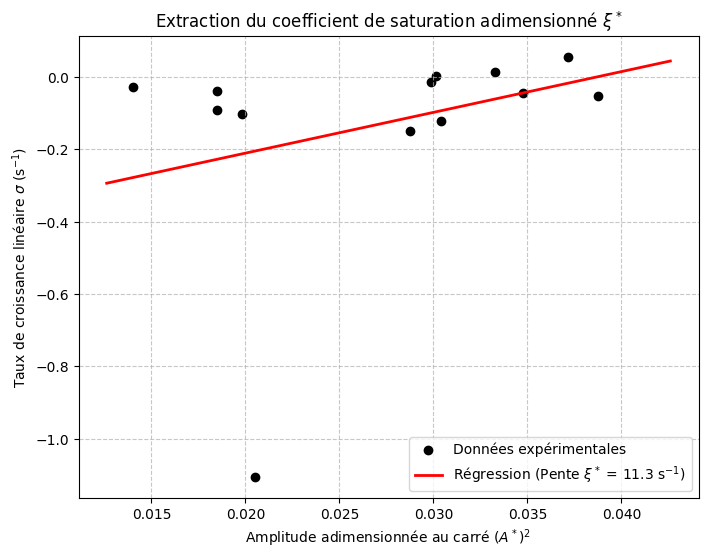


=== Caractérisation du drapeau ===
Coefficient adimensionné (ξ*) : 11.26 s⁻¹
Coefficient dimensionné (ξ)   : 720.78 m⁻².s⁻¹
Qualité de l'ajustement (R²)   : 0.092
-> La pente est positive : Bifurcation supercritique.


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

L_flag = 0.125  # m

# exclure déphasages aberrants
df_propre = df_D_Cd_final[(df_D_Cd_final['Phase_deg'] > 100) & (df_D_Cd_final['Phase_deg'] < 160)].copy()

sigma_vals = df_propre['sigma_max'].values
A_vals = df_propre['Amplitude_m'].values

# adimensionnement
A_star = A_vals / L_flag
A2_star_vals = A_star**2 

plt.figure(figsize=(8, 6))
plt.scatter(A2_star_vals, sigma_vals, color='black', label='Données expérimentales')

# rég linéaire : sigma = ksi_star * (A*)^2 + offset
slope_ksi_star, intercept, r_value, p_value, std_err = linregress(A2_star_vals, sigma_vals)

ksi_star = slope_ksi_star

A2_fit = np.linspace(min(A2_star_vals)*0.9, max(A2_star_vals)*1.1, 50)
sigma_fit = ksi_star * A2_fit + intercept

plt.plot(A2_fit, sigma_fit, 'r-', linewidth=2, label=f'Régression (Pente $\\xi^*$ = {ksi_star:.1f} s$^{{-1}}$)')

plt.xlabel("Amplitude adimensionnée au carré $(A^*)^2$")
plt.ylabel("Taux de croissance linéaire $\\sigma$ (s$^{-1}$)")
plt.title("Extraction du coefficient de saturation adimensionné $\\xi^*$")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

#valeur adimensionnée --> valeur physique pour la suite
ksi_dim = ksi_star / (L_flag**2)

print("\n=== Caractérisation du drapeau ===")
print(f"Coefficient adimensionné (\u03BE*) : {ksi_star:.2f} s\u207B\u00B9")
print(f"Coefficient dimensionné (\u03BE)   : {ksi_dim:.2f} m\u207B\u00B2.s\u207B\u00B9")
print(f"Qualité de l'ajustement (R\u00B2)   : {r_value**2:.3f}")

if ksi_star > 0:
    print("-> La pente est positive : Bifurcation supercritique.")
else:
    print("-> La pente est négative : Bifurcation sous-critique.")

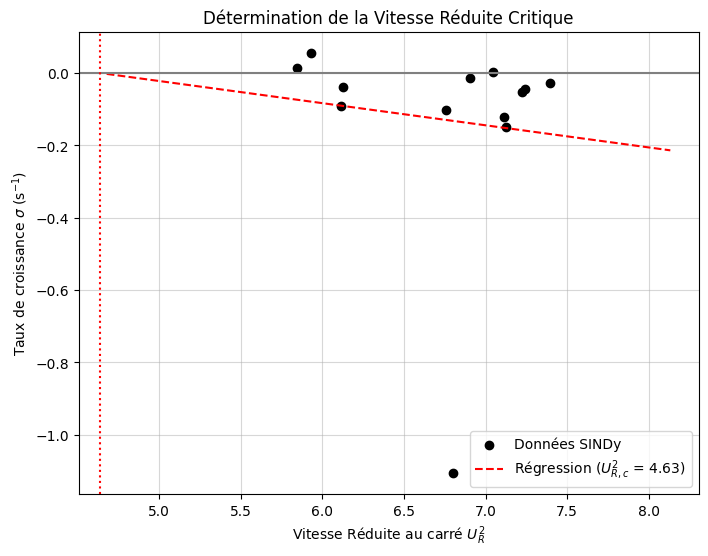


Vitesse Réduite critique (U_R,c) : 2.153
Vitesse critique extrapolée (Uc) : 3.469 m/s (basé sur f_moy = 12.9 Hz)
Qualité de l'ajustement (R²)   : 0.012


In [6]:
U_vals = df_propre['U_vent'].values
f_vals = df_propre['Frequence_Hz'].values

# adimensionnement == vitesse réduite U / (f * L)
U_R = U_vals / (f_vals * L_flag)
UR2_vals = U_R**2

plt.figure(figsize=(8, 6))
plt.scatter(UR2_vals, sigma_vals, color='black', label='Données SINDy')

#régression linéaire : sigma vs U_R^2
slope_UR, intercept_UR, r_value_UR, _, _ = linregress(UR2_vals, sigma_vals)

# point critique adimensionné
UR2_c_estime = -intercept_UR / slope_UR
UR_c_estime = np.sqrt(UR2_c_estime)

UR_fit = np.linspace(min(UR2_vals)*0.8, max(UR2_vals)*1.1, 50)
sigma_fit_UR = slope_UR * UR_fit + intercept_UR

plt.plot(UR_fit, sigma_fit_UR, 'r--', label=f'Régression ($U_{{R,c}}^2$ = {UR2_c_estime:.2f})')

plt.axhline(0, color='gray', linestyle='-')
plt.axvline(UR2_c_estime, color='red', linestyle=':')

plt.xlabel("Vitesse Réduite au carré $U_R^2$")
plt.ylabel("Taux de croissance $\\sigma$ (s$^{-1}$)")
plt.title("Détermination de la Vitesse Réduite Critique")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# U_c (m/s) en utilisant la fréquence moyenne du fluttering
f_mean = np.mean(f_vals)
Uc_estime = UR_c_estime * f_mean * L_flag

print(f"\nVitesse Réduite critique (U_R,c) : {UR_c_estime:.3f}")
print(f"Vitesse critique extrapolée (Uc) : {Uc_estime:.3f} m/s (basé sur f_moy = {f_mean:.1f} Hz)")
print(f"Qualité de l'ajustement (R\u00B2)   : {r_value_UR**2:.3f}")

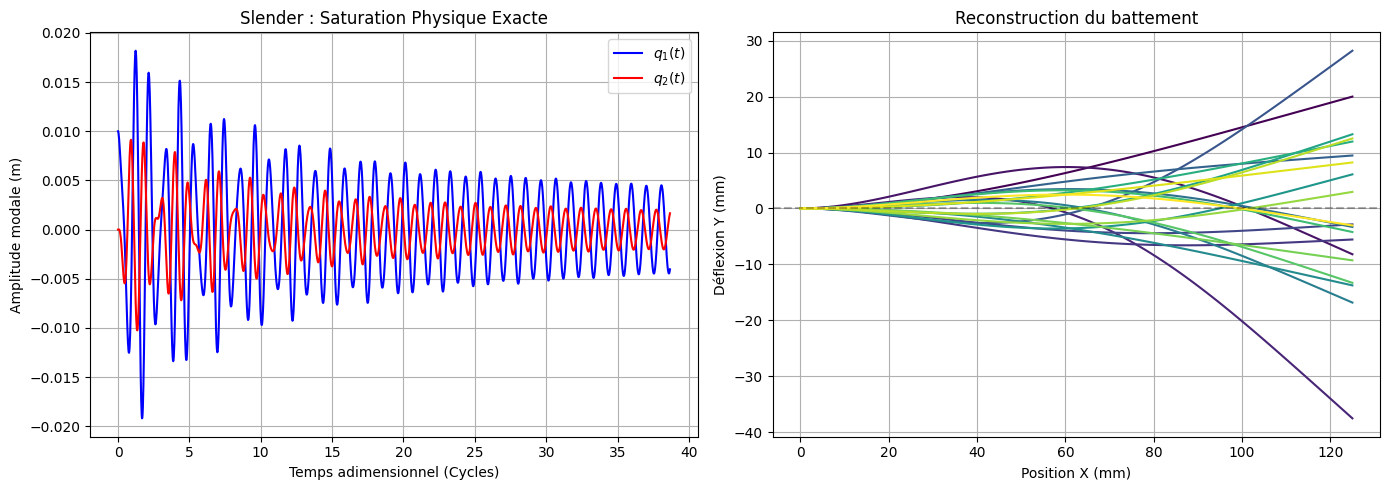


Facteur de conversion Landau -> Galerkin utilisé : 8 * Φ² = 32.00
Valeur finale de ξ_ODE : 23064.98


In [7]:
from scipy.integrate import solve_ivp

L_flag = 0.125
beta_L = np.array([1.87510407, 4.69409113])
s_phys = np.linspace(0, L_flag, 100)

def get_phi(x, beta_val, L):
    b = beta_val / L
    sigma_coef = (np.cosh(beta_val) + np.cos(beta_val)) / (np.sinh(beta_val) + np.sin(beta_val))
    return np.cosh(b*x) - np.cos(b*x) - sigma_coef * (np.sinh(b*x) - np.sin(b*x))

Phi1 = get_phi(s_phys, beta_L[0], L_flag)
Phi2 = get_phi(s_phys, beta_L[1], L_flag)

# conversion Landau --> Galerkin
# 1. fonction de forme au bout du drapeau (tip)
Phi1_tip = get_phi(L_flag, beta_L[0], L_flag) 

# 2. le facteur d'équivalence de Krylov-Bogoliubov
xi_ode = 8 * (Phi1_tip**2) * ksi_dim

def modele_slender(t, y):
    q1, q2, dq1, dq2 = y
    
    lin1 = c1[0]*q1 + c1[1]*q2 + c1[2]*dq1 + c1[3]*dq2
    lin2 = c2[0]*q1 + c2[1]*q2 + c2[2]*dq1 + c2[3]*dq2
    
    # amortissement non-linéaire basé sur la conversion exacte
    nl_damp1 = - xi_ode * (q1**2) * dq1
    nl_damp2 = - xi_ode * (q2**2) * dq2
    
    ddq1 = lin1 + nl_damp1
    ddq2 = lin2 + nl_damp2
    
    return [dq1, dq2, ddq1, ddq2]

t_max = 3.0 
t_eval = np.linspace(0, t_max, 2000)

# pichenette de 1 cm (0.01)
etat_initial = [0.01, 0, 0, 0] 

# solveur
solution = solve_ivp(modele_slender, [0, t_max], etat_initial, t_eval=t_eval, method='Radau')

q1_sim = solution.y[0]
q2_sim = solution.y[1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1 : amplitudes avec temps adimensionnel
temps_adim = solution.t * f_mean
ax1.plot(temps_adim, q1_sim, 'b-', label='$q_1(t)$')
ax1.plot(temps_adim, q2_sim, 'r-', label='$q_2(t)$')
ax1.set_title("Slender : Saturation Physique Exacte")
ax1.set_xlabel("Temps adimensionnel (Cycles)")
ax1.set_ylabel("Amplitude modale (m)")
ax1.legend()
ax1.grid(True)

# 2 : reconstruction 1D
indices_temps = list(range(0, len(solution.t), max(1, len(solution.t)//20)))
couleurs = plt.cm.viridis(np.linspace(0, 1, len(indices_temps)))

for idx, color in zip(indices_temps, couleurs):
    forme_drapeau = q1_sim[idx] * Phi1 + q2_sim[idx] * Phi2
    ax2.plot(s_phys * 1000, forme_drapeau * 1000, color=color, linewidth=1.5)

ax2.set_title("Reconstruction du battement")
ax2.set_xlabel("Position X (mm)")
ax2.set_ylabel("Déflexion Y (mm)")
ax2.axhline(0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"\nFacteur de conversion Landau -> Galerkin utilisé : 8 * \u03A6\u00B2 = {8*(Phi1_tip**2):.2f}")
print(f"Valeur finale de \u03BE_ODE : {xi_ode:.2f}")

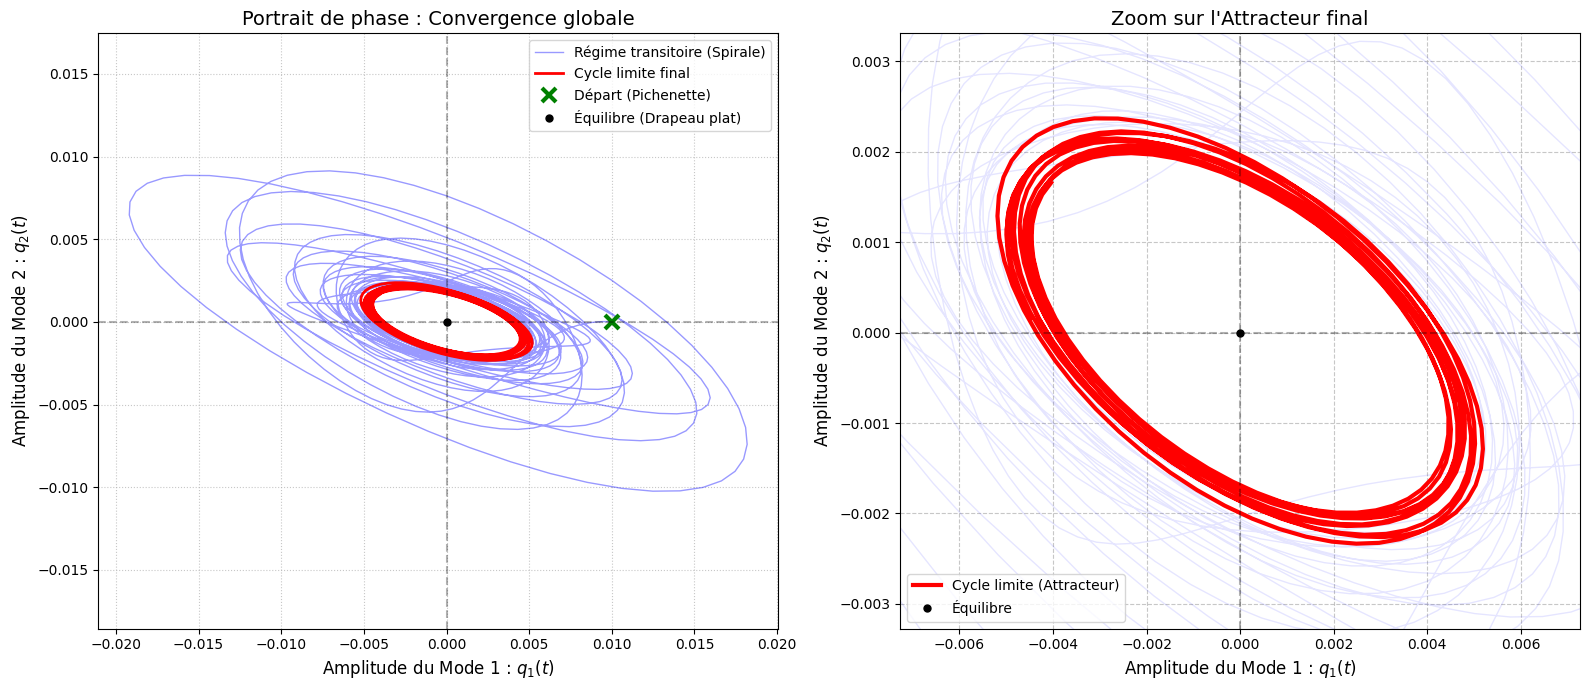

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax_glob, ax_zoom) = plt.subplots(1, 2, figsize=(16, 7))

#  vue globale
ax_glob.plot(q1_sim, q2_sim, 'b-', alpha=0.4, linewidth=1, label='Régime transitoire (Spirale)')
ax_glob.plot(q1_sim[-500:], q2_sim[-500:], 'r-', linewidth=2, label='Cycle limite final')
ax_glob.plot(q1_sim[0], q2_sim[0], 'gx', markersize=10, markeredgewidth=3, label='Départ (Pichenette)')
ax_glob.plot(0, 0, 'ko', markersize=5, label='Équilibre (Drapeau plat)')

ax_glob.set_title("Portrait de phase : Convergence globale", fontsize=14)
ax_glob.set_xlabel("Amplitude du Mode 1 : $q_1(t)$", fontsize=12)
ax_glob.set_ylabel("Amplitude du Mode 2 : $q_2(t)$", fontsize=12)
ax_glob.axhline(0, color='k', linestyle='--', alpha=0.3)
ax_glob.axvline(0, color='k', linestyle='--', alpha=0.3)
ax_glob.grid(True, linestyle=':', alpha=0.7)
ax_glob.legend(loc='best')
ax_glob.axis('equal') # pas d'ellipse déformée par l'échelle globale

#  isole les 500 derniers points pour calculer la taille exacte de l'ellipse
q1_fin = q1_sim[-500:]
q2_fin = q2_sim[-500:]

ax_zoom.plot(q1_sim, q2_sim, 'b-', alpha=0.1, linewidth=1) #spirale cla en fond
ax_zoom.plot(q1_fin, q2_fin, 'r-', linewidth=3, label='Cycle limite (Attracteur)')
ax_zoom.plot(0, 0, 'ko', markersize=5, label='Équilibre')

ax_zoom.set_title("Zoom sur l'Attracteur final", fontsize=14)
ax_zoom.set_xlabel("Amplitude du Mode 1 : $q_1(t)$", fontsize=12)
ax_zoom.set_ylabel("Amplitude du Mode 2 : $q_2(t)$", fontsize=12)
ax_zoom.axhline(0, color='k', linestyle='--', alpha=0.3)
ax_zoom.axvline(0, color='k', linestyle='--', alpha=0.3)
ax_zoom.grid(True, linestyle='--', alpha=0.7)

marge_q1 = (np.max(q1_fin) - np.min(q1_fin)) * 0.2
marge_q2 = (np.max(q2_fin) - np.min(q2_fin)) * 0.2

# limites à l'axe X et Y
ax_zoom.set_xlim(np.min(q1_fin) - marge_q1, np.max(q1_fin) + marge_q1)
ax_zoom.set_ylim(np.min(q2_fin) - marge_q2, np.max(q2_fin) + marge_q2)

ax_zoom.legend(loc='best')

plt.tight_layout()
plt.show()

Lancement du DMD sur la matrice de taille : (200, 2180)


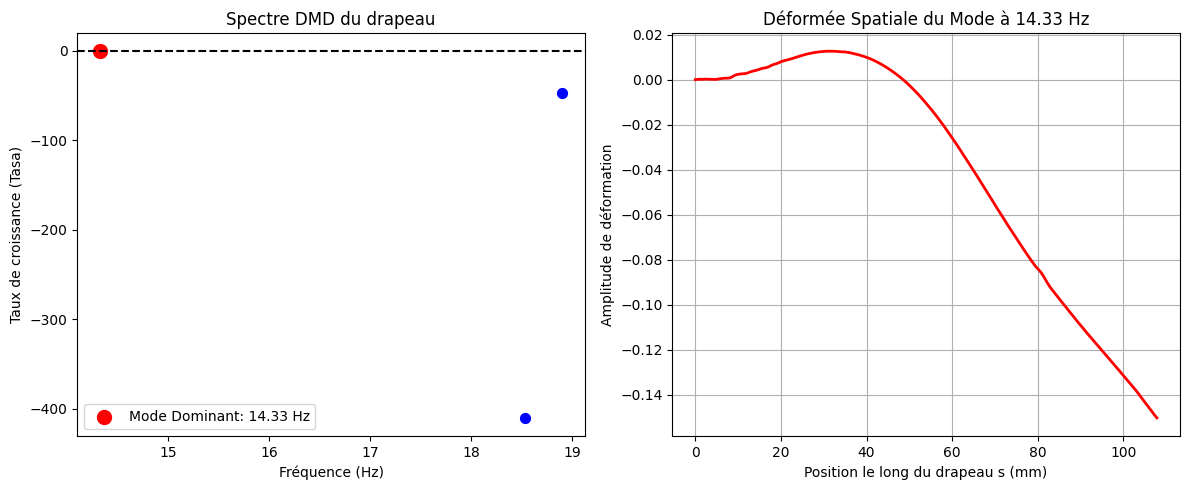

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- TA FONCTION DMD ---
def koopman_dmd(u, dt, ns=None):
    tic = time.time()
    n_dof, n_snap = u.shape
    
    # 1. SVD
    U_r, sigma, Vh = np.linalg.svd(u[:, 0:-1], full_matrices=False)
    
    if ns is None:
        ns = min(n_dof, n_snap - 1)
    ns = min(ns, len(sigma))
    
    # 3. Proyectar
    U_ns = U_r[:, 0:ns]
    sigma_inv = 1.0 / sigma[0:ns]
    Vh_ns = Vh[0:ns, :]
    
    # Matriz S
    S = U_ns.conj().T @ u[:, 1:] @ Vh_ns.conj().T @ np.diag(sigma_inv)
    
    # 4. Eigen
    mui, yi = np.linalg.eig(S)
    
    # 5. Modos
    phii = U_ns @ yi
    
    # 6. Frecuencias (On utilise dt pour avoir de vrais Hertz !)
    lam = np.log(mui) / dt
    frec = lam.imag / (2 * np.pi)
    tasa = lam.real
    
    return phii, mui, frec, tasa

v = 52.0  # voltage à  analyser
fps = 1000.0 # caméra à 1000 Hz
dt = 1.0 / fps

data = np.load(f'new_data_out/{v}_slender.npz')
Y_clean = data['Y'] # Forme : (Temps, Espace)
S_coord = data['S'][0, :] # Abscisse curviligne du drapeau

u_mat = Y_clean.T

#soustrait la position du mât (indice 0) à tout le reste du drapeau= pince virtuellement le pixel 0 à Y=0 pour tous les instants t !
u_mat = u_mat - u_mat[0, :] 


print(f"Lancement du DMD sur la matrice de taille : {u_mat.shape}")

#retient les 10 premiers modes (pour filtrer le bruit)
phii, mui, frec, tasa = koopman_dmd(u_mat, dt=dt, ns=10)

#cherche fréquences positives (physiques)
idx_pos = frec > 0
frec_pos = frec[idx_pos]
tasa_pos = tasa[idx_pos]
phii_pos = phii[:, idx_pos]

#mode dominant (a la plus grande amplitude / plus petit amortissement) = dont la 'tasa' est la plus proche de 0
idx_dominant = np.argmax(tasa_pos)
frec_dominant = frec_pos[idx_dominant]
mode_dominant = phii_pos[:, idx_dominant]

plt.figure(figsize=(12, 5))

#spectre DMD (Spectre de Koopman)
plt.subplot(1, 2, 1)
plt.scatter(frec_pos, tasa_pos, color='blue', s=50)
plt.scatter(frec_dominant, tasa_pos[idx_dominant], color='red', s=100, label=f'Mode Dominant: {frec_dominant:.2f} Hz')
plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Taux de croissance (Tasa)")
plt.title("Spectre DMD du drapeau")
plt.legend()

#forme du mode dominant (Partie Réelle = forme spatiale)
plt.subplot(1, 2, 2)
plt.plot(S_coord, mode_dominant.real, 'r-', linewidth=2)
plt.xlabel("Position le long du drapeau s (mm)")
plt.ylabel("Amplitude de déformation")
plt.title(f"Déformée Spatiale du Mode à {frec_dominant:.2f} Hz")
plt.grid(True)

plt.tight_layout()
plt.show()

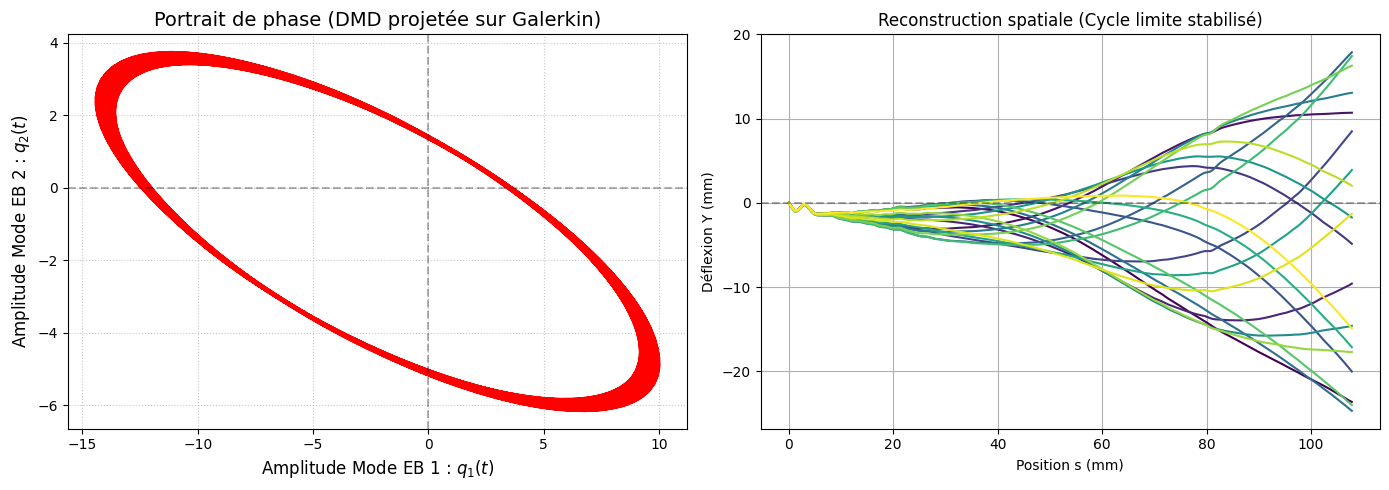

In [18]:
# phii (les modes spatiaux complexes), mui (les valeurs propres discrètes)
# S_coord (l'axe spatial s du drapeau), dt (pas de temps de la vidéo)

n_modes = phii.shape[1]
n_snaps = 2000 # Le nombre de pas de temps que tu veux simuler

#calculer les amplitudes initiales "b" (projection de la première image sur les modes)
# Y_clean[:, 0] est la première image de la vidéo (t=0)
# u_mat[:, 0] représente l'état spatial complet du drapeau à t=0
b, _, _, _ = np.linalg.lstsq(phii, u_mat[:, 0], rcond=None)


#reconstruire la dynamique temporelle de chaque mode : q(t)

#forcer le régime permanent : module des valeurs propres = 1 (Tasa = 0 strict)
mui_stable = mui / np.abs(mui)

Vandermonde = np.vander(mui_stable, n_snaps, increasing=True)
Dynamics = b[:, np.newaxis] * Vandermonde

#tri des modes
#cherche les modes physiques (fréquence > 0)
frec_hz = np.imag(np.log(mui)) / (dt * 2 * np.pi)
idx_physiques = np.where(frec_hz > 0.5)[0] #ignore les fréquences quasi-nulles

# ==> on prend les deux qui ont la plus grande amplitude initiale (|b|)
idx_tries = sorted(idx_physiques, key=lambda i: abs(b[i]), reverse=True)
mode_1_idx = idx_tries[0] # Le mode dominant (Ton gros point rouge !)
mode_2_idx = idx_tries[1] # Le deuxième harmonique

#séparer modes pour le portrait de phase
q1_dmd = np.real(Dynamics[mode_1_idx, :])
q2_dmd = np.real(Dynamics[mode_2_idx, :])

# reconstruction spatio-temporelle complète du drapeau
Y_reconstruit = np.real(phii @ Dynamics)


#Y_reconstruit par la DMD (Taille : Espace x Temps) ==> matrice Phi des modes d'Euler-Bernoulli (Taille : Espace x 4)
# On projette le drapeau propre sur la physique d'Euler-Bernoulli
q_physiques, _, _, _ = np.linalg.lstsq(Phi[:, 0:2], Y_reconstruit, rcond=None)

# q_physiques contient q1(t) et q2(t) de Galerkin, lissés et stabilisés par la DMD
q1_galerkin_propre = q_physiques[0, :]
q2_galerkin_propre = q_physiques[1, :]



fig, (ax_phase, ax_recon) = plt.subplots(1, 2, figsize=(14, 5))

#portrait de Phase
ax_phase.plot(q1_galerkin_propre, q2_galerkin_propre, 'r-', linewidth=2)
ax_phase.set_title("Portrait de phase (DMD projetée sur Galerkin)", fontsize=14)
ax_phase.set_xlabel("Amplitude Mode EB 1 : $q_1(t)$", fontsize=12)
ax_phase.set_ylabel("Amplitude Mode EB 2 : $q_2(t)$", fontsize=12)
ax_phase.axhline(0, color='k', linestyle='--', alpha=0.3)
ax_phase.axvline(0, color='k', linestyle='--', alpha=0.3)
ax_phase.grid(True, linestyle=':', alpha=0.7)


indices_temps = list(range(0, n_snaps, max(1, n_snaps//20)))
couleurs = plt.cm.viridis(np.linspace(0, 1, len(indices_temps)))

for idx, color in zip(indices_temps, couleurs):
    ax_recon.plot(S_coord, Y_reconstruit[:, idx], color=color, linewidth=1.5)

ax_recon.set_title("Reconstruction spatiale (Cycle limite stabilisé)")
ax_recon.set_xlabel("Position s (mm)")
ax_recon.set_ylabel("Déflexion Y (mm)")
ax_recon.axhline(0, color='k', linestyle='--', alpha=0.3)
ax_recon.grid(True)

plt.tight_layout()
plt.show()